# Assignment 2: Formula 1 Data

**Sally Choi**  

**DATASCI 530**

## Introduction

Formula 1 (F1) is an international racing championship in which drivers race for teams, known as constructors, at events around the world. The datasets record when races took place, which drivers and teams competed, and how many points they earned. This report connects those records to compare leading teams across two time periods (1981-2020, 2001-2020) and examine Ferrari’s drivers and performance.

#### **Key Findings:**

The Ferrari team earned the most points in both periods. Mercedes ranked second in both periods, while Red Bull replaced McLaren in third place in the shorter period. Ferrari had 25 different drivers represented in race results between 1981 and 2020, and its strongest year by total race points was 2018, with 571 points. Also, there were more countries hosting F1 races in the recent years.

intro paragrph for f1
3 points of what i learned 
coceptual instead of .csv etc. (can lay-people language)

In [39]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data preparation for questions a and b

I will use the points each team/constructor earned in each race to calculate its total over the years. These records identify races and constructors by ID numbers, so I will match the race IDs to race information to merge the year, and match the constructor IDs to constructor information to merge the constructor name.

I will add the points earned in individual races rather than the running season totals. Adding running totals would count points from earlier races more than once.

In [41]:
# Import the datasets
constructor_results = pd.read_csv("data_raw/constructor_results.csv")
races = pd.read_csv("data_raw/races.csv")
constructors = pd.read_csv("data_raw/constructors.csv")

# column names for reference
# print(constructor_results.columns)
# print(races.columns)
# print(constructors.columns)

In [55]:
# check for missing values in columns of interest
# print(constructor_results.isna().sum())
# print(races.isna().sum())
# print(constructors.isna().sum())

# only the "status" column has missing values out of all three datasets which is not a relevant column, but will still fix
# see unique values in status
# print(pd.unique(constructor_results["status"]))

# replace with readable null
constructor_results = constructor_results.replace("\\N", np.nan)

In [ ]:
# check that each ID is unique
print(len(races) == len(pd.unique(races["raceId"])))
print(len(constructors) == len(pd.unique(constructors["constructorId"])))

### Merging datasets

Merge year and name of constructors from 2 different datasets into the main dataset for analysis.
After merging, check if any rows are omitted in result of merging or if there are any present missing values.

In [53]:
# merge year using raceId
constructor_data_wyear = pd.merge(constructor_results,
    races[["raceId", "year"]],
    on = "raceId",
    how = "left")

# merge constructor name using constructorId
constructor_data_all = pd.merge(constructor_data_wyear, 
    constructors[["constructorId", "name"]],
    on = "constructorId",
    how = "left")

# check if any rows were lost
print("Rows before merging:", len(constructor_results))
print("Rows after merging:", len(constructor_data_all))

# check missing values in the columns needed for the analysis
missing_values = constructor_data_all[["raceId", "constructorId", "year", "name", "points"]].isna().sum()
if (missing_values == 0).all(): 
    print("No missing values in columns of interest")

# check that year and points are numeric
# print(constructor_data_all[["year", "points"]].dtypes)

Rows before merging: 12170
Rows after merging: 12170
No missing values in columns of interest


- Datasets have unique identifiers

- The merges preserve all 12,170 constructor-result observations

- There are no missing values in relevant columns after merging, so no observations need to be removed

- Year and points are numeric

## (a) Constructors with the most points, 1981–2020

#### Question: Which three constructors earned the most points between 1981 and 2020? How many total points did each of them earn? How do the total points for each constructor compare with the average across constructors?

**Explanation of process**

- I will restrict the data to 1981 through 2020 (including both endpoints).

- Sum race points for each constructor and sort the totals from highest to lowest to select the top three.

- Get mean of total points across al constructors in this period to get the constructor points mean (including constructors with no points as they were still part of the F1 races). Compare this number to the top three constructors' points (difference from the average and divided from average to see percentage increase from average)

In [63]:
# filter years, sum points by constructor, and sort the totals
constructor_data_a = (constructor_data_all
                        .query("year >= 1981 & year <= 2020")
                        .groupby("name")
                        .agg(total_points_a = ("points", "sum"))
                        .sort_values(by = "total_points_a", ascending = False)
                        )

# display(constructor_data_a)

In [79]:
# calculate the average across all constructors
average_points_a = constructor_data_a["total_points_a"].mean()
print(f"Average earned points for all constructors 1981-2020: {average_points_a:.2f}")

# extract top 3 (add .copy since i had warning --> copy the top three so new columns can be added safely)
top_three_a = constructor_data_a.iloc[0:3, :].copy()

# compare each team's total with the average (create columns)
top_three_a["difference_from_average"] = (top_three_a["total_points_a"] - average_points_a)
top_three_a["divided_from_average"] = (top_three_a["total_points_a"] / average_points_a)

# final table displaying answers
table_a = (
    top_three_a
    .rename_axis("Constructor")
    .rename(columns = {
        "total_points_a": "Total points",
        "difference_from_average": "Points above average",
        "divided_from_average": "Times the average"
    })
    .style.format({
        "Total points": "{:,.1f}",
        "Points above average": "{:,.1f}",
        "Times the average": "{:.2f}"
    })
    .set_caption(
        f"Table 1. Top constructors, 1981–2020 "
        f"(average: {average_points_a:,.2f} points)"
    )
)

display(table_a)

Average earned points for all constructors 1981-2020: 532.24


,Total points,Points above average,Times the average
Constructor,,,
Ferrari,"7,374.0","6,841.8",13.85
Mercedes,"5,685.0","5,152.8",10.68
McLaren,"5,229.5","4,697.3",9.83


### Findings

- The top three constructors with the most amount of total points between 1981 and 2020 are Ferrari, Mercedes, and McLaren with the 7374 points, 5685 points, and 5229.5 points respectively.

- The average total of points across all constructors over the time period is roughly 532 (which includes constructors without any points). Compared to this, Ferrari has ~13.9 times more points than the average as the lead, Mercedes with ~10.7 times the average points, and McLaren with ~9.8 times.

## (b) Constructors with the most points, 2001–2020

#### Question: Which three constructors earned the most points between 2001 and 2020? How many total points did each of them earn? How do the total points for each constructor compare with the average across constructors?

**Explanation of process**

Same process as question (a), using the same merged data file, but the query for year will be restricted from 2001 to 2020 (including both endpoints).

In [71]:
# filter years, sum points by constructor, and sort the totals
constructor_data_b = (constructor_data_all
                        .query("year >= 2001 & year <= 2020")
                        .groupby("name")
                        .agg(total_points_b = ("points", "sum"))
                        .sort_values(by = "total_points_b", ascending = False)
                        )

# display(constructor_data_b)

In [80]:
# calculate the average across all constructors
average_points_b = constructor_data_b["total_points_b"].mean()
print(f"Average earned points for all constructors 2001-2020: {average_points_b:.2f}")

# extract top 3
top_three_b = constructor_data_b.iloc[0:3, :].copy()

# compare each team's total with the average (creat column)
top_three_b["difference_from_average"] = (top_three_b["total_points_b"] - average_points_b)
top_three_b["divided_from_average"] = (top_three_b["total_points_b"] / average_points_b)

# final table displaying answers
table_b = (
    top_three_b
    .rename_axis("Constructor")
    .rename(columns = {
        "total_points_b": "Total points",
        "difference_from_average": "Points above average",
        "divided_from_average": "Times the average"})
    .style.format({
        "Total points": "{:,.1f}",
        "Points above average": "{:,.1f}",
        "Times the average": "{:.2f}"})
    .set_caption(
        f"Table 2. Top constructors, 2001–2020 "
        f"(average: {average_points_b:,.2f} points)")
        )

display(table_b)

Average earned points for all constructors 2001-2020: 786.01


,Total points,Points above average,Times the average
Constructor,,,
Ferrari,"5,862.0","5,076.0",7.46
Mercedes,"5,685.0","4,899.0",7.23
Red Bull,"5,043.5","4,257.5",6.42


### Findings

- The top three constructors with the most total points between 2001 and 2020 are Ferrari, Mercedes, and Red Bull, with 5,862 points, 5,685 points, and 5,043.5 points respectively.

- The average total points across all constructors over this period is roughly 786, including constructors with no points. Compared to this, Ferrari earned ~7.5 times the average points, Mercedes earned ~7.2 times, and Red Bull earned ~6.4 times.

- Red Bull replaced McLaren in third place during the more recent period. The average total points per constructor also increased from about 532 to 786, so the top three teams’ totals were smaller multiples of the average.

## (c) Changes in constructor rankings

#### Question: How did the rankings change across the two time periods?

**Explanation of process**

- Use the total points for all constructors already calculated in (a) and (b) to rank the constructor within each period (highest total points = rank 1) Ranking all constructors before selecting the top 10 lets me see where a team moved if it left the top 10 across time.

- Merge the two rankings using the constructor name, so each row compares the same constructor across the two periods. Use an outer merge to keep constructors that appear in either period. A missing rank means the constructor is not represented in that period, rather than that it received zero points.

- Select constructors that were in the top 10 in either period. This keeps the comparison focused on the leading teams from (a) and (b), while including any team that entered or left the top 10.

The periods cover different numbers of years, so comparing totals alone does not directly show whether a constructor moved ahead of another team.
The periods also overlap: 2001–2020 is part of 1981–2020. This comparison shows how the rankings change when 1981–2000 is excluded, rather than comparing two separate time periods.

In [19]:
# rank all constructors by total points in each period
# dense to give tied total points the same rank without skipping the next rank
constructor_data_a["rank_a"] = (constructor_data_a["total_points_a"]
                                .rank(method = "dense", ascending = False))
constructor_data_b["rank_b"] = (constructor_data_b["total_points_b"]
                                .rank(method = "dense", ascending = False))

# merge rankings by name (name is the index after grouping)
ranking_comparison = pd.merge(constructor_data_a[["rank_a"]],
    constructor_data_b[["rank_b"]],
    on = "name",
    how = "outer")

# select teams in the top 10 in both periods
ranking_top = (ranking_comparison
                .query("rank_a <= 10 | rank_b <= 10")
                .sort_values(by = "rank_a"))

# make table look better
ranking_table = (ranking_top
    .rename(columns = {"rank_a": "Rank, 1981–2020",
                       "rank_b": "Rank, 2001–2020"})
    .style.format("{:.0f}")
    .set_caption("Constructor rankings: teams in the top three in either period"))
display(ranking_table)

,"Rank, 1981–2020","Rank, 2001–2020"
name,,
Ferrari,1,1
Mercedes,2,2
McLaren,3,4
Red Bull,4,3
Williams,5,5
Renault,6,6
Force India,7,7
Benetton,8,22
Lotus F1,9,8


### Findings

- Ferrari and Mercedes remained in first and second place in both periods. The main change in the top three was Red Bull moving from fourth to third, replacing McLaren, which moved from third to fourth.

- Williams, Renault, and Force India kept their positions in fifth, sixth, and seventh place. Sauber also remained in tenth place.

- Among the teams shown, Benetton had the largest change, moving from eighth to twenty-second when only 2001–2020 was included. Lotus F1 moved from ninth to eighth, while Toro Rosso moved from eleventh to ninth.

- Overall, most leading teams kept similar rankings. These changes show how excluding the earlier years affects the standings based on total points, so they do not necessarily mean a team became better or worse from one season to the next.

## (d) Different Ferrari drivers, 1981–2020

#### Question: How many different drivers did Ferrari have between 1981 and 2020?

**Explanation of process**

- Import "results" because it includes the driver ID, constructor ID, and race ID for each driver's race result. (the constructor-results data used earlier does not identify individual drivers)

- Check missing values before cleaning, then merge the year column from "races" and the constructor name column from "constructors". I will check that the merges preserve the row count and that the variables needed for this question are not missing.

- Restrict the data to Ferrari between 1981 and 2020 (including both endpoints), then get the unique driver IDs and count them.

I am counting unique driver IDs rather than rows because a driver can appear in many races. A driver who competed for Ferrari in several seasons, or left and returned, should still count only once.

In [98]:
# import driver race results
results = pd.read_csv("data_raw/results.csv")

# check recognized missing values and column types before replacing
# print(results.isna().sum())
# print(results.dtypes)

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
dtype: int64

In [94]:
# merge year using raceId
results_wyear = pd.merge(results,
    races[["raceId", "year"]],
    on = "raceId",
    how = "left")

# merge constructor name using constructorId
results_all = pd.merge(results_wyear,
    constructors[["constructorId", "name"]],
    on = "constructorId",
    how = "left")

# check if any rows were lost or added
print("Rows before merging:", len(results))
print("Rows after merging:", len(results_all))

# check missing values in the columns needed for this question
missing_values_results_merged = results_all[["driverId", "constructorId", "year", "name"]].isna().sum()

missing_values_results_merged = results.isna().sum()
if (missing_values_results_merged == 0).all(): 
    print("No missing values in the merged dataset")

Rows before merging: 25840
Rows after merging: 25840
No missing values in the merged dataset


In [97]:
# select Ferrari race results in the requested years
ferrari_results = results_all.query(
    'name == "Ferrari" & year >= 1981 & year <= 2020')

# count different driver IDs, not the number of race-result rows
ferrari_driver_ids = pd.unique(ferrari_results["driverId"])
number_ferrari_drivers = len(ferrari_driver_ids)
print(f"Different Ferrari drivers from 1981 to 2020: {number_ferrari_drivers} drivers")

Different Ferrari drivers from 1981 to 2020: 25 drivers


### Findings

- The merges preserve all 25,840 driver-result observations. There are no missing values in driver ID, constructor ID, year, or constructor name after merging, so no observations need to be removed because of missing values in these variables. (Missing values in other columns do not affect this count because those columns are not used to identify the drivers)

- Ferrari has 25 individual drivers represented in race results between 1981 and 2020.

- Each driver is counted once, regardless of the number of races or seasons they participated in for Ferrari.

## (e) Ferrari's best year, 1981–2020

#### Question: What was the best year for Ferrari between 1981 and 2020?

**Explanation of process**

- Define "best year" as the year with the highest total race points for Ferrari. This keeps the measure of performance consistent with the points-based comparisons made in questions a and b.

- Use the merged constructor-results data, restrict the observations to Ferrari from 1981 through 2020, and sum the points by year. (each row in the new table will represent one year rather than one race)

- Sort the annual totals from highest to lowest and find the maximum. I will select all years equal to the maximum so that a tie would not be left out.

- Display the best year in a table and plot (line plot) the race points by year to determine the trend throughout the whole period.

This definition identifies the largest recorded points total. It does not measure championship position, number of wins, or points per race, and it does not account for the differences in race counts or scoring rules across seasons.

In [113]:
# filter ferrari observations and sum points by year
ferrari_yearly_points = (constructor_data_all
    .query('name == "Ferrari" & year >= 1981 & year <= 2020')
    .groupby("year")
    .agg(total_points = ("points", "sum"))
    .sort_values(by = "total_points", ascending = False))

# find the highest annual total and keep any tied years
highest_points = ferrari_yearly_points["total_points"].max()
ferrari_best_year = ferrari_yearly_points.query(
    "total_points == @highest_points")

print(ferrari_best_year)

# get top 5 years with highest race points
ferrari_top_five = ferrari_yearly_points.iloc[0:5, :]

# format the table
top_five_table = (
    ferrari_top_five
    .rename_axis("Year")
    .rename(columns = {"total_points": "Total race points"})
    .style.format({"Total race points": "{:,.1f}"})
    .set_caption("Ferrari's top five years by race points, 1981–2020")
    )

display(top_five_table)

      total_points
year              
2018         571.0


,Total race points
Year,
2018,571.0
2017,522.0
2019,504.0
2015,428.0
2012,400.0


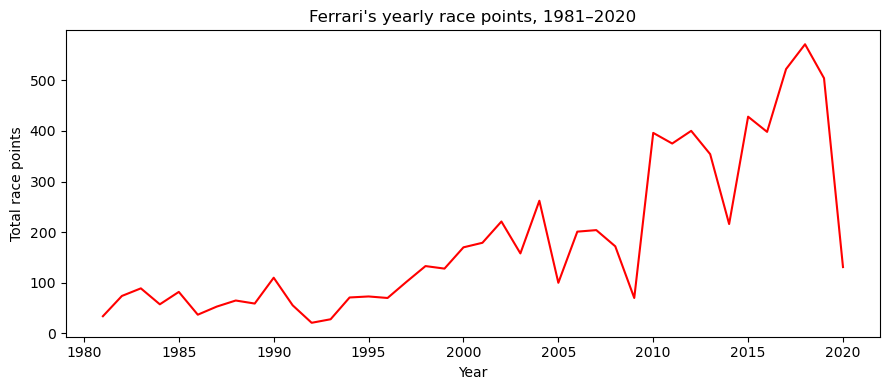

In [102]:
# put years in chronological order before doing the line chart
ferrari_yearly_points.sort_values(by = "year")["total_points"].plot(
    kind = "line", color = "red", figsize = (9, 4))

plt.title("Ferrari's yearly race points, 1981–2020")
plt.xlabel("Year")
plt.ylabel("Total race points")
plt.tight_layout()
plt.show()

### Findings

- Ferrari's best year by total race points is 2018, with 571 points. This is the highest yearly total in the 1981–2020 period, and no other year ties this total.

- According to the table, next highest totals are 522 points in 2017 and 504 points in 2019. The line chart places the 2018 peak within the full sequence of yearly totals. The chart is ordered by year so that the line shows changes.

- The results indicate that the best time frame for Ferrari was 2017-2019, reaching their peak in 2018.

- This result means 2018 was Ferrari's best year under the total race points. Again, it does not imply that Ferrari won the championship that year or that it was the strongest season under every measure of performance.

## (f) Distribution of countries for races between periods

#### Question: How did the hosting location of F1 races change between 1981–2000 and 2001–2020?

### Data preparation

I will use race information to identify the year each event took place. To identify the host country, I will match each race's circuit ID with the circuit information, which records the location of the track. This will allow me to count races by their actual location rather than their event name. Each race will be counted, and will be counted as one regardless of drivers, tracks, how many races in that year or in the country, etc.

Before merging, I will check the required columns for missing values and confirm that each circuit ID appears only once in the circuit information. I will also standardize country names so that different labels for the same country are not counted separately.

In [ ]:
# import circuit data
circuits = pd.read_csv("data_raw/circuits.csv")

# check missing values and replace to readable n/a
missing = circuits[["circuitId", "country"]].isna().sum()
if (missing== 0).all(): 
    print("No missing values in country or circuit ID columns")

# check the country labels before cleaning
# print(pd.unique(circuits["country"]))

# standardize country names
circuits["country"] = circuits["country"].replace({
    "USA": "United States",
    "UK": "United Kingdom",
    "UAE": "United Arab Emirates"})
# combined countries labeled USA and United States into United States as one name to avoid counting same country separately
# print(pd.unique(circuits["country"]))

# confirm that each circuit ID appears only once
print("Circuit IDs are unique:",
      len(circuits) == len(pd.unique(circuits["circuitId"])))

No missing values in country or circuit ID columns
Circuit IDs are unique: True


### Merging datasets

Select race ID, year, and circuitID from races dataset and merge country by circuitID.

In [127]:
# attach the host country to each race
races_country = pd.merge(
    races[["raceId", "year", "circuitId"]],
    circuits[["circuitId", "country"]],
    on = "circuitId",
    how = "left")

# check the number of observations before and after merging
print("Rows before merging:", len(races))
print("Rows after merging:", len(races_country))

# check missing values in the merged columns
missing_values_f = races_country[
    ["raceId", "year", "circuitId", "country"]].isna().sum()

if (missing_values_f == 0).all(): 
    print("No missing values in dataset after merging")

Rows before merging: 1102
Rows after merging: 1102
No missing values in dataset after merging


### Explanation of process

- Divide the races into two separate periods: 1981–2000 and 2001–2020. (each period covers 20 years, including both endpoints)

- Count the total number of races and different host countries in each period. This shows whether the racing calendar became larger and what host countries were included.

- Count races by country in each period and merge the counts using the country name. Keep countries represented in either period. If a country hosted no races during one period, its count will be zero.

- Divide each country's race count by the total number of races in that period and multiply by 100. This gives the percentage of races hosted by each country within that distinct time period.

I will compare percentages in the plot because the two periods contain different total numbers of races. This helps distinguish a change in where races were held from growth in the overall racing calendar.

In [129]:
# separate races into two non-overlapping periods
races_early = races_country.query("year >= 1981 & year <= 2000")
races_later = races_country.query("year >= 2001 & year <= 2020")

# summarize the size and geographic reach of each period
geographic_summary = pd.DataFrame({
    "Period": ["1981–2000", "2001–2020"],
    "Number of races": [len(races_early), len(races_later)],
    "Number of host countries": [
        len(pd.unique(races_early["country"])),
        len(pd.unique(races_later["country"]))]
        })

display(
    geographic_summary.style
    .hide(axis = "index")
    .set_caption("Formula 1 races and host countries by period"))

Period,Number of races,Number of host countries
1981–2000,321,20
2001–2020,372,26


In [131]:
# count races by country in each period
country_counts_early = (races_early
    .groupby("country")
    .agg(races_early = ("raceId", "count")))

country_counts_later = (races_later
    .groupby("country")
    .agg(races_later = ("raceId", "count")))

# keep countries that hosted races in either period
country_comparison = pd.merge(
    country_counts_early,
    country_counts_later,
    on = "country",
    how = "outer")

# an absent country-period combination means zero hosted races
country_comparison = country_comparison.fillna(0)

# calculate each country's percentage of races within each period
country_comparison["share_early"] = (
    country_comparison["races_early"] / len(races_early) * 100)

country_comparison["share_later"] = (
    country_comparison["races_later"] / len(races_later) * 100)

# calculate combined race counts
country_comparison["total_races"] = (
    country_comparison["races_early"]
    + country_comparison["races_later"])

### Location distribution of races

The grouped bar chart compares the percentage of races hosted by each country in the two periods. Countries are ordered by their combined number of races across 1981–2020, with the most frequent hosts at the top.

The chart includes every country represented in either period so that countries appearing only in the earlier or later period remain visible. A missing bar means that the country hosted no races in that period.

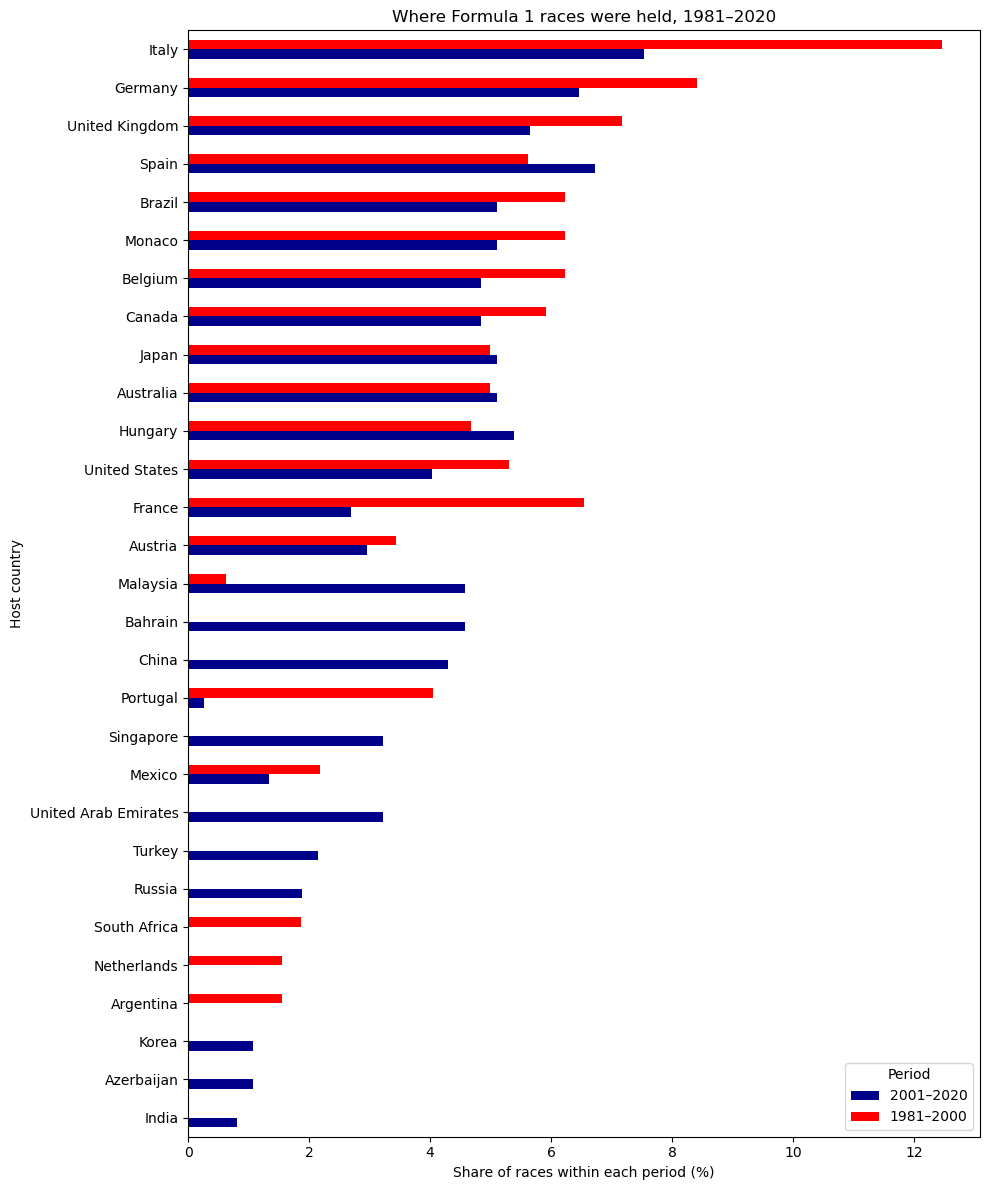

In [139]:
country_plot = (country_comparison
    .sort_values(by = "total_races", ascending = True)
    [["share_later", "share_early"]]
    .rename(columns = {
        "share_early": "1981–2000",
        "share_later": "2001–2020"}
        ))

# compare the two periods with horizontal grouped bars
country_plot.plot(
    kind = "barh",
    stacked = False,
    figsize = (10, 12),
    color = ["darkblue", "red"])

plt.title("Where Formula 1 races were held, 1981–2020")
plt.xlabel("Share of races within each period (%)")
plt.ylabel("Host country")
plt.legend(title = "Period")
plt.tight_layout()
plt.show()

## (g) Findings: What does this tell us about Formula 1?

- F1 races were held in more countries during the later period. The number of host countries increased from 20 in 1981–2000 to 26 in 2001–2020. The number of races also increased from 321 to 372, showing increases in races as well as geographically broader.

- Italy remained a major hosting country, but its share of races fell from about 5% across time. Germany being the second hosting most races, but its share also fell about 2%. Following trend, most major countries hosting the F1 races fell with their shares over time. But this share was redistributed to other countries. For instance, Malaysia's share increased from about 4%, showing a shift in where events were held.

- Also, several countries hosted races in the later period but not in the earlier period. Bahrain, China, Singapore, and the United Arab Emirates hosted races in the later period but not the earlier one, showing F1's growing presence in Asia and the Middle East.

- Overall, F1 brought races to more countries and increased in race counts. However, these data show event locations, so they cannot tell us whether fan interest or attendance increased.